<a href="https://colab.research.google.com/github/ml-da/sales_analysis/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import auth
from google.colab import drive
from google.cloud import bigquery

auth.authenticate_user()
project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)
drive.mount('/content/drive')

Mounted at /content/drive


#QUERY:

In [ ]:
query = """
SELECT
  s.date as order_date,
  o.ga_session_id as session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.name as traffic_source,
  sp.channel as traffic_channel,
  a.id as account_id,
  a.is_verified,
  a.is_unsubscribed,
  p.category,
  p.name,
  p.price as revenue,
  p.short_description
FROM `data-analytics-mate.DA.order` o
JOIN data-analytics-mate.DA.session s
  ON o.ga_session_id = s.ga_session_id
JOIN data-analytics-mate.DA.session_params sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN data-analytics-mate.DA.account_session acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN data-analytics-mate.DA.account a
  ON acs.account_id = a.id
JOIN data-analytics-mate.DA.product p
  ON o.item_id = p.item_id

"""
df = client.query(query).to_dataframe()

df.head()

,order_date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,category,name,revenue,short_description
0,2020-11-06,7799937037,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,(referral),Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,2020-11-10,4020421879,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(direct),Direct,653378,1,0,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,2020-11-24,6717382496,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(referral),Social Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2020-11-26,2093497337,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(direct),Direct,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,2020-12-03,9506718330,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,(referral),Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"


In [ ]:
df.to_csv('/content/drive/My Drive/sales_analysis_data.csv', index=False)

#Dataset Overview:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_date         33538 non-null  dbdate 
 1   session_id         33538 non-null  Int64  
 2   continent          33538 non-null  object 
 3   country            33538 non-null  object 
 4   device             33538 non-null  object 
 5   browser            33538 non-null  object 
 6   mobile_model_name  33538 non-null  object 
 7   operating_system   33538 non-null  object 
 8   language           22531 non-null  object 
 9   traffic_source     33538 non-null  object 
 10  traffic_channel    33538 non-null  object 
 11  account_id         2781 non-null   Int64  
 12  is_verified        2781 non-null   Int64  
 13  is_unsubscribed    2781 non-null   Int64  
 14  category           33538 non-null  object 
 15  name               33538 non-null  object 
 16  revenue            335

Dataset overview: 18 total columns, including 5 numeric fields. Specifically, 4 are Int64 (ga_session_id, id, is_verified, is_unsubscribed) and one is float64 (revenue). Includes one dbdate column

In [ ]:
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_date         33538 non-null  dbdate 
 1   session_id         33538 non-null  Int64  
 2   continent          33538 non-null  object 
 3   country            33538 non-null  object 
 4   device             33538 non-null  object 
 5   browser            33538 non-null  object 
 6   mobile_model_name  33538 non-null  object 
 7   operating_system   33538 non-null  object 
 8   language           22531 non-null  object 
 9   traffic_source     33538 non-null  object 
 10  traffic_channel    33538 non-null  object 
 11  account_id         2781 non-null   Int64  
 12  is_verified        2781 non-null   Int64  
 13  is_unsubscribed    2781 non-null   Int64  
 14  category           33538 non-null  object 
 15  name               33538 non-null  object 
 16  revenue            335

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

bool_cols = ['is_verified', 'is_unsubscribed']
for col in bool_cols:
    df[col] = df[col].astype('boolean')


df['session_id'] = df['session_id'].astype('int64')

df['account_id'] = df['account_id'].astype('UInt32')

print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_date         33538 non-null  datetime64[ns]
 1   session_id         33538 non-null  int64         
 2   continent          33538 non-null  object        
 3   country            33538 non-null  object        
 4   device             33538 non-null  object        
 5   browser            33538 non-null  object        
 6   mobile_model_name  33538 non-null  object        
 7   operating_system   33538 non-null  object        
 8   language           22531 non-null  object        
 9   traffic_source     33538 non-null  object        
 10  traffic_channel    33538 non-null  object        
 11  account_id         2781 non-null   UInt32        
 12  is_verified        2781 non-null   boolean       
 13  is_unsubscribed    2781 non-null   boolean       
 14  catego

Optimized data schema: Memory usage reduced from 24 MB to 23.4 MB.

In [ ]:
print(f"Number of unique sessioins: {df['session_id'].nunique()}")

Number of unique sessioins: 33538


In [ ]:
print(f"Date period: {df['order_date'].min()} - {df['order_date'].max()} ({df['order_date'].nunique()} days)")

Date period: 2020-11-01 00:00:00 - 2021-01-27 00:00:00 (88 days)


The highest concentration of missing values is observed in the account_id, is_verified, and is_unsubscribed columns (30,757 records). This is primarily due to a high volume of guest checkouts (unregistered users). Additionally, the language column has 1,007 missing entries, likely attributable to technical glitches.

#Descriptive Analysis

In [ ]:
total_revenue = df['revenue'].sum()

/tmp/ipykernel_3225/1350563438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = countries_sales, x = 'percentage', y = 'country', palette = 'viridis')


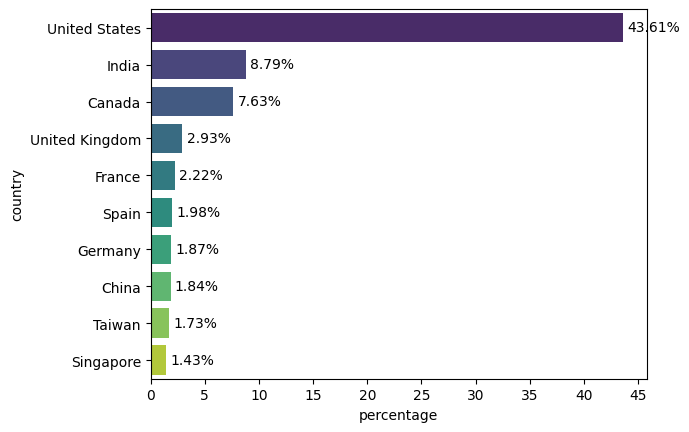

In [ ]:
countries_sales = df.groupby('country')['revenue'].sum().sort_values(ascending = False).head(10).reset_index()
countries_sales['percentage'] = (countries_sales['revenue'] / total_revenue) * 100
top_countries = countries_sales.sort_values(by='percentage', ascending=False)
ax = sns.barplot(data = countries_sales, x = 'percentage', y = 'country', palette = 'viridis')
x_ticks = np.arange(0, top_countries['percentage'].max() + 5, 5)
plt.xticks(x_ticks)
for container in ax.containers:
  ax.bar_label(container, fmt = '%.2F%%', padding =3)
plt.show()

The USA dominates total revenue, maintaining a nearly 5x lead over the second-place country.

In [ ]:
top_country = df.groupby('country', observed=True)['revenue'].sum().idxmax()
print(f"Top country by sales: {top_country}")

Top country by sales: United States


/tmp/ipykernel_3225/3803211346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax = axes[0], data = top_10_global, x = 'revenue', y = 'category', order=top_10_global['category'], palette = 'viridis')
/tmp/ipykernel_3225/3803211346.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax = axes[1], data = top_10_country, x = 'revenue', y = 'category', order=top_10_country['category'], palette = 'viridis')


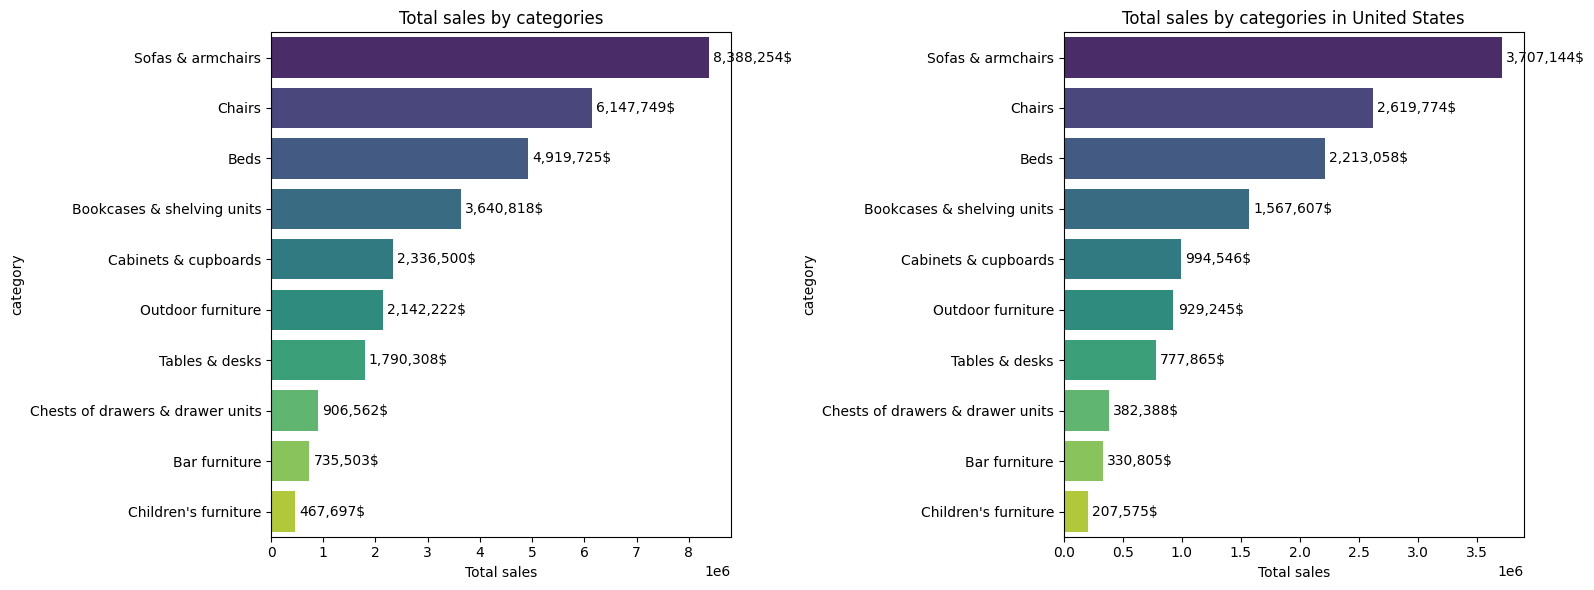

In [ ]:
top_10_global = df.groupby('category', observed=True)['revenue'].sum().sort_values(ascending=False).head(10).reset_index()
top_10_country = df[df['country'] == top_country].groupby('category', observed=True)['revenue'].sum().sort_values(ascending=False).head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

sns.barplot(ax = axes[0], data = top_10_global, x = 'revenue', y = 'category', order=top_10_global['category'], palette = 'viridis')

for container in axes[0].containers:
  axes[0].bar_label(container, padding = 3, fmt = '{:,.0f}$')

axes[0].set_xlabel("Total sales")

axes[0].set_title("Total sales by categories")

sns.barplot(ax = axes[1], data = top_10_country, x = 'revenue', y = 'category', order=top_10_country['category'], palette = 'viridis')

for container in axes[1].containers:
  axes[1].bar_label(container, padding = 3, fmt = '{:,.0f}$')

axes[1].set_xlabel("Total sales")

axes[1].set_title(f"Total sales by categories in {top_country}")

plt.tight_layout()
plt.show()

In [ ]:
print(f"US sales as a percentage of total revenue: {df[df['country'] == top_country]['revenue'].sum() /total_revenue * 100 :.2f}%")

US sales as a percentage of total revenue: 43.61%


In [ ]:
device_analysis = df.groupby(['device', 'mobile_model_name'], observed=True)['revenue'].sum().reset_index()

device_analysis['percentage'] = (device_analysis['revenue'] / total_revenue) * 100

top_devices = device_analysis.sort_values(by='percentage', ascending=False)

print(f"Total revenue: {total_revenue:,.2f}$")

Total revenue: 31,971,731.10$


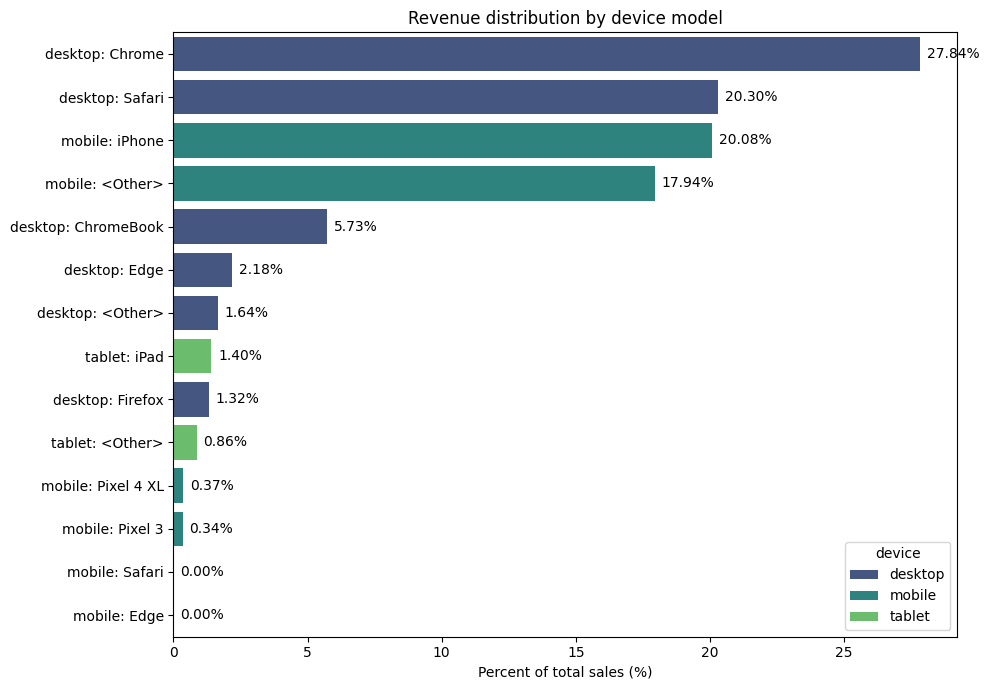

In [ ]:
plt.figure(figsize=(10, 7))

top_devices['device_model'] = (top_devices['device'] + ": " + top_devices['mobile_model_name'])
ax = sns.barplot(data=top_devices, x='percentage', y='device_model', hue='device', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5)

plt.title('Revenue distribution by device model')
plt.xlabel('Percent of total sales (%)')
plt.ylabel('')

plt.tight_layout()
plt.show()

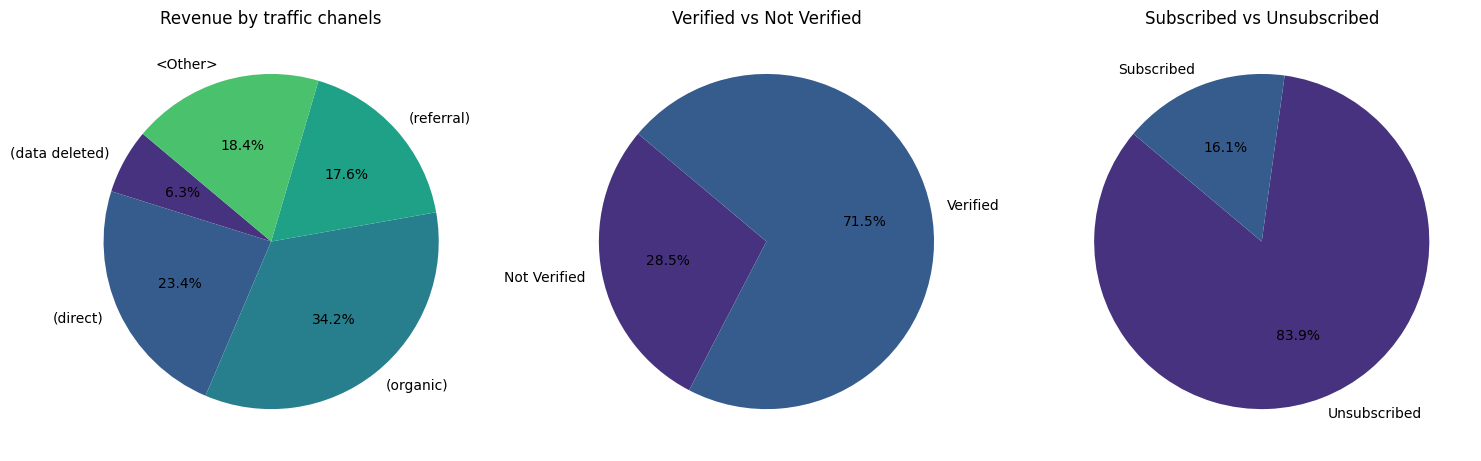

In [ ]:
pie_data = df.groupby('traffic_source', observed=True)['revenue'].sum()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
ax[0].set_title('Revenue by traffic chanels')

verified_counts = df[~df['is_verified'].isna()].groupby('is_verified')['account_id'].count()
ax[1].pie(verified_counts.values, labels=['Verified' if x == 1 else 'Not Verified' for x in verified_counts.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
ax[1].set_title("Verified vs Not Verified")

subscribed_counts = df[~df['is_verified'].isna()].groupby('is_unsubscribed')['account_id'].count()
ax[2].pie(subscribed_counts.values, labels=['Subscribed' if x == 1 else 'Unsubscribed' for x in subscribed_counts.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
ax[2].set_title("Subscribed vs Unsubscribed")

plt.tight_layout()
plt.show()

The revenue distribution by traffic source highlights strong brand authority among new users, with Organic Search accounting for 34.2%. Additionally, a significant share of traffic (17.6%) is driven by Referral programs, suggesting high customer satisfaction and a strong propensity to recommend the store.

The churn rate for email subscriptions is anomalously high at 83.9%, indicating an urgent need to pivot the current email marketing strategy.

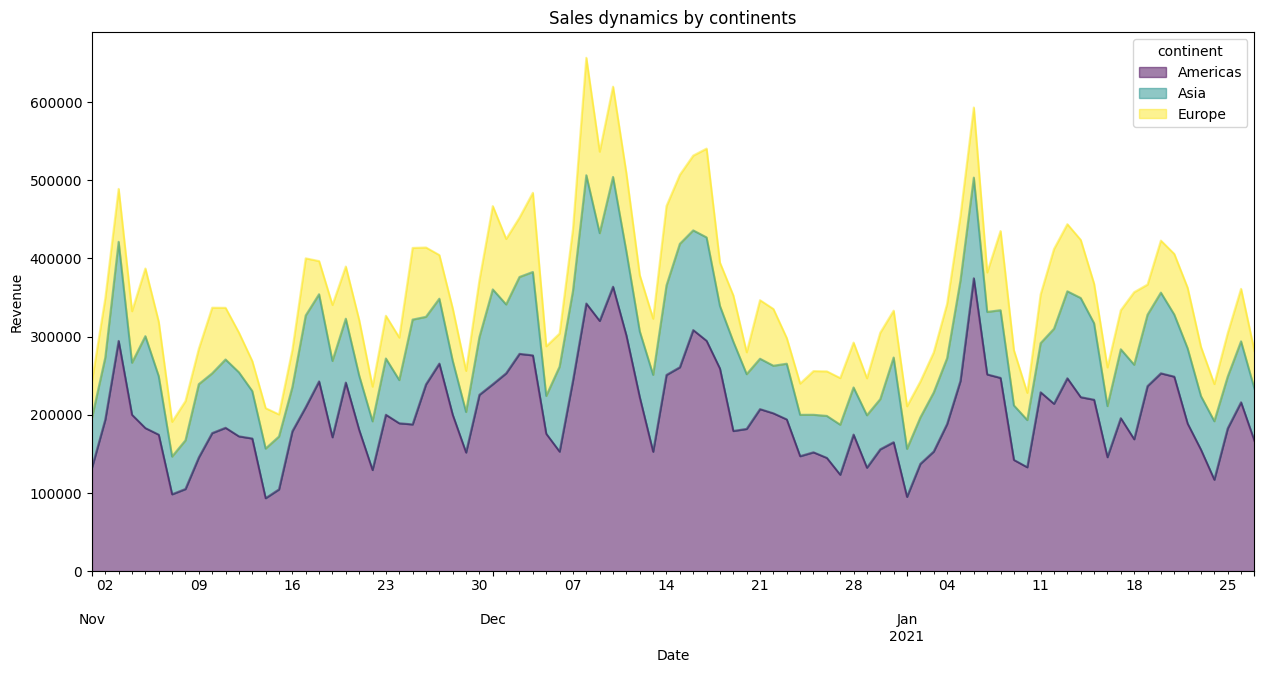

In [ ]:
df[df['continent'].isin(['Americas', 'Europe', 'Asia'])].pivot_table(index = 'order_date', columns = 'continent', values = 'revenue', aggfunc= 'sum').plot.area(alpha=0.5, figsize = (15,7), colormap='viridis',)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Sales dynamics by continents")
plt.show()

- **Compositional Stability & Scalability**

Despite fluctuations in the total aggregate, the visual proportions of the segments remain nearly constant. This indicates a stable customer base structure but highlights a lack of differential scaling—no single region is outpacing others in terms of growth.

- **Correlation & Risk Analysis**

All three segments expand and contract in near-perfect synchronization, suggesting that global drivers (such as seasonality or major promotional campaigns) impact all continents uniformly. There is a lack of geographical hedging; no region acts as a buffer or 'safeguard' to offset downturns in the American market.

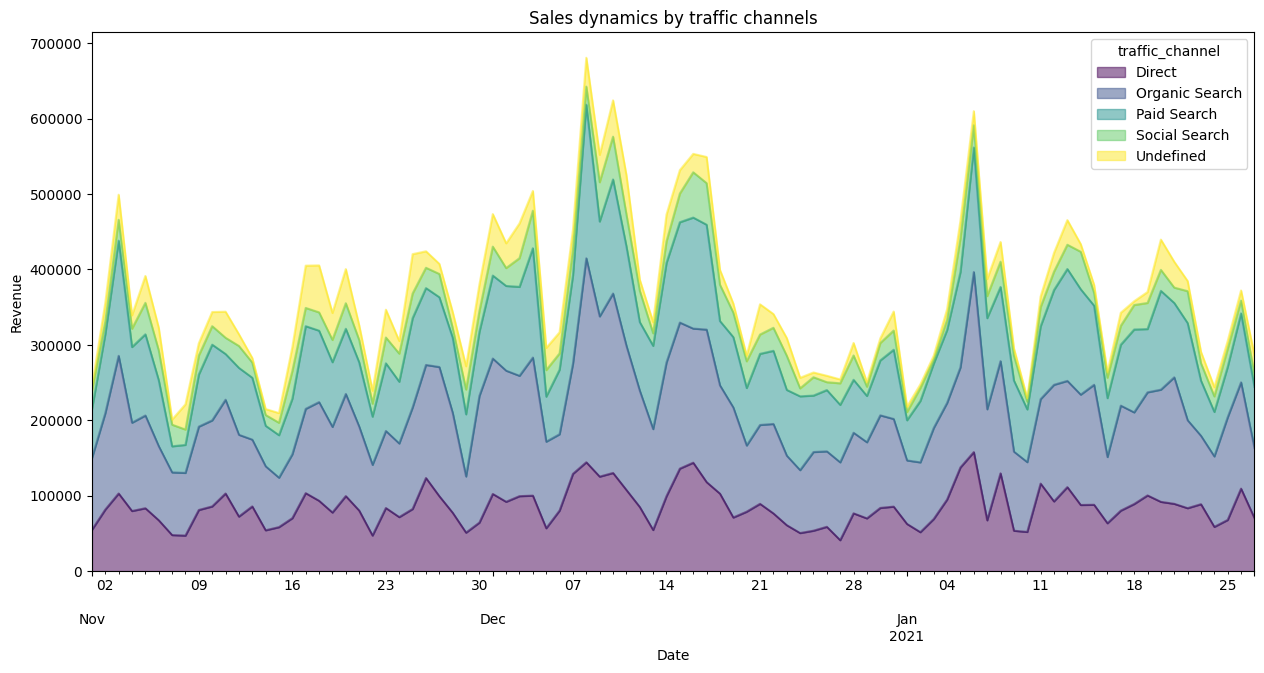

In [ ]:
df.pivot_table(index = 'order_date', columns = 'traffic_channel', values = 'revenue', aggfunc= 'sum').plot.area(alpha=0.5, figsize = (15,7), colormap='viridis',)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Sales dynamics by traffic channels")
plt.show()

- **Channel Dominance & Brand Equity**

Core Revenue Drivers: The majority of revenue is generated through Direct and Organic Search channels. This underscores strong brand salience and effective SEO optimization.

- **Growth Correlation**

Synchronized Dynamics: All channels exhibit near-perfect correlation, expanding and contracting in unison. This indicates that sales peaks (e.g., mid-December) are driven by macro-market demand or global promotional events rather than a breakthrough in any specific acquisition channel.

- **Paid Media Contribution**

Role of Paid Traffic: While Paid Search and Social account for a smaller share of the total mix, they act as an incremental layer, amplifying growth during peak periods and providing necessary scale during high-demand windows.

- **Retention & Business Core**

Direct Channel Resilience: The Direct segment maintains the most consistent volume, even during overall market contractions. This represents the foundational loyalty of the customer base, serving as the business's 'backbone' that ensures operational stability.

- **Data Integrity Issues**

Attribution Gaps (Undefined): A significant portion of revenue attributed to 'Undefined' signals issues with UTM tagging or tracking configurations. This unattributed revenue creates 'noise' in the data, preventing a 100% accurate assessment of marketing ROI.

#Deep Diagnostic Analysis

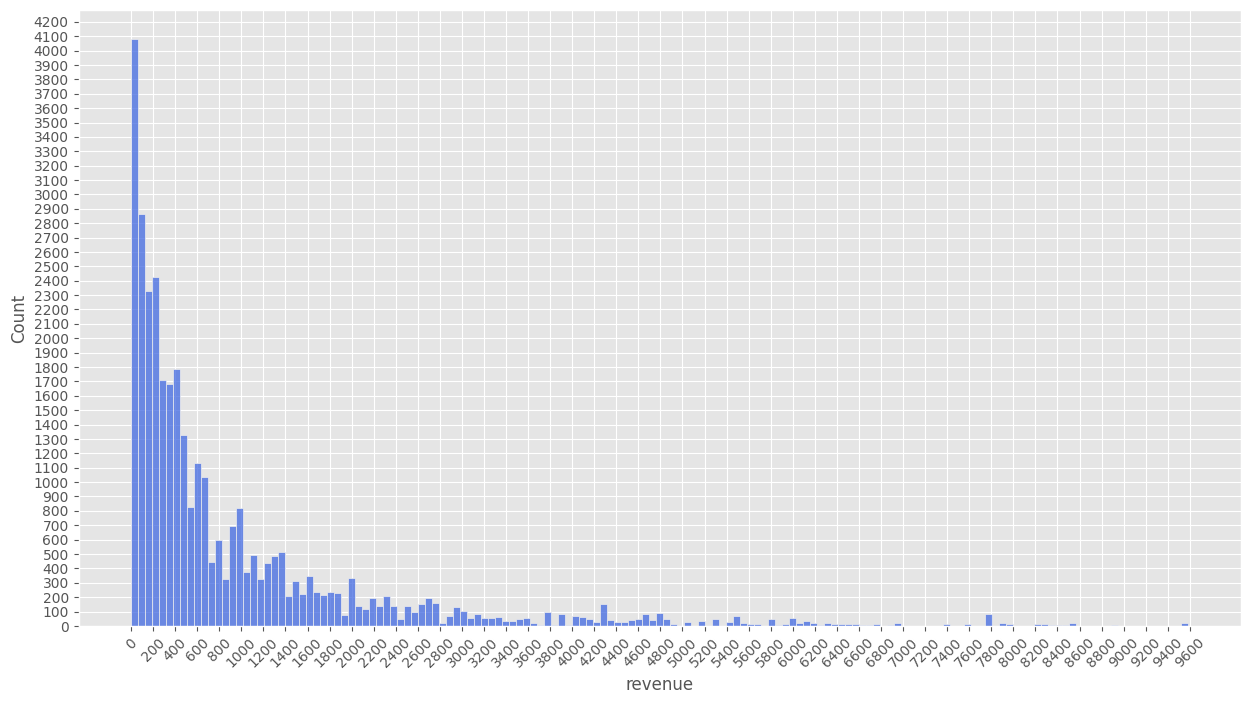

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize = (15,8))
sns.histplot(data = df, x = 'revenue', color = 'royalblue')
x_ticks = np.arange(0, df['revenue'].max() + 200, 200)
y_ticks = np.arange(0, plt.gca().get_ylim()[1], 100)
plt.xticks(x_ticks, rotation = 45)
plt.yticks(y_ticks)
plt.show()

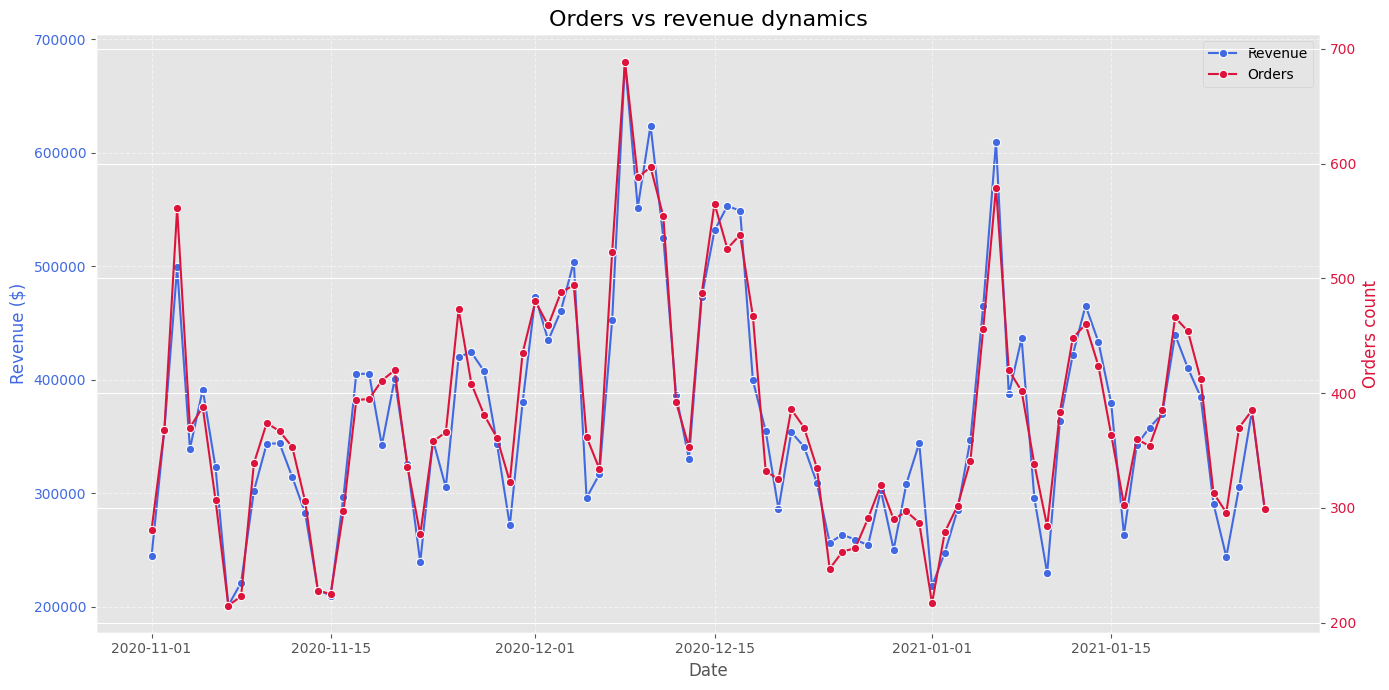

In [ ]:
daily_stats = df.groupby('order_date').agg({
    'revenue': 'sum',
    'session_id': 'count'
}).reset_index()
daily_stats.columns = ['order_date', 'revenue', 'orders']

fig, ax1 = plt.subplots(figsize=(14, 7))

color_rev = 'royalblue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)', color=color_rev, fontsize=12)
sns.lineplot(data=daily_stats, x='order_date', y='revenue', ax=ax1, color=color_rev, marker='o', label='Revenue', legend = False)
ax1.tick_params(axis='y', labelcolor=color_rev)
ax1.ticklabel_format(style='plain', axis='y')

ax2 = ax1.twinx()
color_orders = 'crimson'
ax2.set_ylabel('Orders count', color=color_orders, fontsize=12)
sns.lineplot(data=daily_stats, x='order_date', y='orders', ax=ax2, color=color_orders, marker='o', label='Orders', legend = False)
ax2.tick_params(axis='y', labelcolor=color_orders)

plt.title('Orders vs revenue dynamics', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
daily_stats = df.groupby('order_date').agg({'session_id' : 'count', 'revenue' : 'sum'}).reset_index()

pearson_corr, p_value = stats.spearmanr(daily_stats['session_id'], daily_stats['revenue'])

print(f"Spearman Correlation: {pearson_corr:.4f} (p={p_value:.2e})")

Spearman Correlation: 0.9510 (p=1.35e-45)


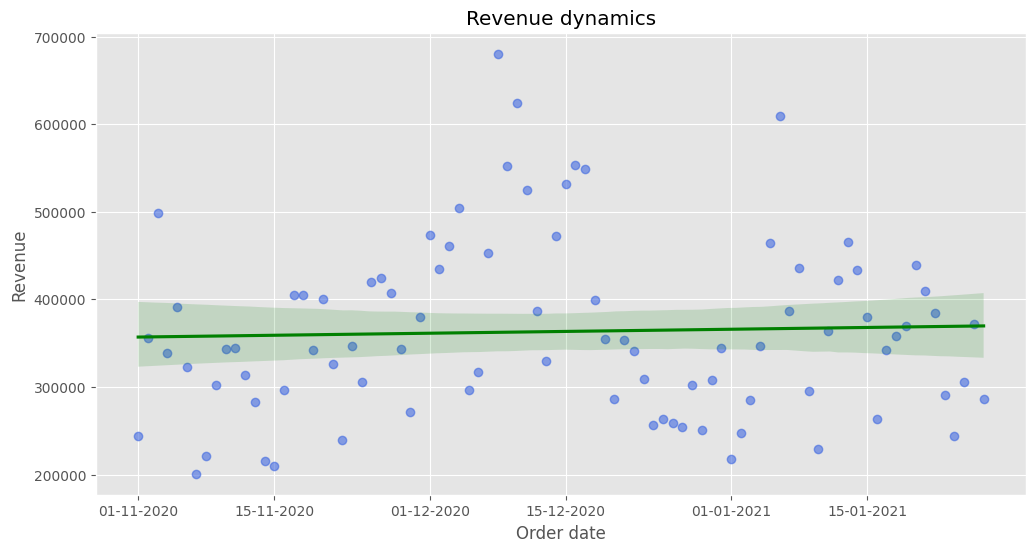

In [ ]:
import matplotlib.dates as mdates
plt.figure(figsize = (12, 6))
dates_sales = df.groupby('order_date')['revenue'].sum().reset_index()
revenue_dynamics = dates_sales.copy()
revenue_dynamics['order_date_ordinal'] = revenue_dynamics['order_date'].map(mdates.date2num)
ax = sns.regplot(data=revenue_dynamics, x='order_date_ordinal', y='revenue', scatter_kws={'alpha':0.6, 'color':'royalblue'}, line_kws={'color':'green'})
plt.xlabel("Order date")
plt.ylabel("Revenue")
plt.title("Revenue dynamics")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.show()

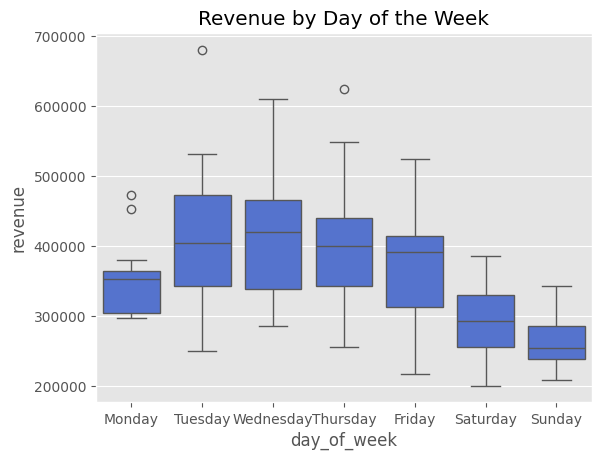

In [ ]:
dates_sales['day_of_week'] = dates_sales['order_date'].dt.day_name()
sns.boxplot(data=dates_sales, x='day_of_week', y='revenue', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], color = 'royalblue')
plt.title("Revenue by Day of the Week")
plt.show()

- **Trend & Volatility Diagnostics**

The analyzed period is characterized by a revenue plateau, with the regression line remaining strictly flat. Despite notable daily fluctuations, there is no evidence of fundamental or systemic growth. The high variance relative to the trendline indicates that daily performance is driven by stochastic factors or short-term tactical promotions rather than a systematic scaling of the customer base.

- **Hypothesis Testing: Identifying Volatility Drivers**

Hypothesis: Revenue volatility is driven by isolated high-ticket transactions (outliers) rather than shifts in underlying consumer demand.

Findings: The distribution exhibits extreme positive skewness, with a "long tail" of transactions reaching up to $9,500. However, a dual-axis correlation analysis reveals that every revenue spike is accompanied by a proportional surge in order volume.

Statistical Verification: Given the right-skewed distribution and the presence of price outliers, Spearman’s rank correlation was employed to ensure robustness against non-normal distribution and extreme values.

Spearman’s Correlation (ρ): 0.9510

Statistical Significance (p-value): 1.35e-45

Findings: The test yielded a coefficient of 0.9510, confirming a nearly perfect monotonic relationship. The fact that the Spearman result closely aligns with the Pearson coefficient proves that outliers (high-ticket sales) do not distort the overall business trend. The extremely low p-value (1.35e-45) eliminates any possibility of stochastic coincidence.

Conclusion: The "Outlier Hypothesis" is rejected. Revenue fluctuations are a function of increased customer traffic and conversion density. There is a near-perfect positive correlation between revenue and order counts, moving in lockstep.

- **Seasonality & Performance Patterns**

Contrary to typical retail benchmarks, the business demonstrates an inverted seasonality profile. Peak median revenue and operational consistency are concentrated between Tuesday and Thursday, with Wednesday identified as the peak volume day. Sales experience significant attrition during weekends, suggesting a customer base primarily composed of B2B clients or professionals making procurement decisions during business hours.

- **Strategic Recommendations & Action Plan**

To break the current stagnation and transition from a plateau to a growth trajectory, the following data-driven strategies are proposed:

Maximize Peak-Period Throughput: Instead of subsidizing underperforming weekends, the strategy should focus on doubling down on the Tuesday–Thursday window. Increasing marketing spend and operational capacity during these high-conversion periods will yield a higher ROI.

Shift from Tactical to Systemic Growth: Since volatility is driven by traffic volume rather than "whales," the primary growth lever is funnel efficiency. Efforts should pivot from chasing isolated high-value sales to scalable customer acquisition and retention.

Address the "Signal-to-Noise" Ratio: Given the high dependence on stochastic factors, a rigorous audit of short-term promotions is required to distinguish between genuine market demand and artificial, non-sustainable spikes.

In [ ]:
df.pivot_table(index = 'traffic_channel', columns = 'device', values = 'session_id', aggfunc = 'count', margins=True, margins_name = 'Total')

device,desktop,mobile,tablet,Total
traffic_channel,,,,
Direct,4655,2985,160,7800
Organic Search,7011,4655,255,11921
Paid Search,5261,3574,207,9042
Social Search,1594,1065,57,2716
Undefined,1181,834,44,2059
Total,19702,13113,723,33538


In [ ]:
top_10_categories = df.groupby('category')['revenue'].sum().sort_values(ascending = False).head(10).index
top_10_countries = df.groupby('country')['revenue'].sum().sort_values(ascending = False).head(10).index
df[(df['country'].isin(top_10_countries)) & (df['category'].isin(top_10_categories))].pivot_table(index = 'country', columns = 'category', values = 'revenue', aggfunc = 'sum', margins = True, margins_name = 'Total')

category,Bar furniture,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Chests of drawers & drawer units,Children's furniture,Outdoor furniture,Sofas & armchairs,Tables & desks,Total
country,,,,,,,,,,,
Canada,51724.0,354772.0,278981.9,181802.0,417740.8,71952.0,30264.0,185322.8,692427.5,132678.0,2397665.0
China,9143.0,107051.0,67909.1,42745.0,130800.0,19827.0,9805.0,31876.0,144430.0,16845.5,580431.6
France,11199.0,116414.0,73830.0,59101.5,134029.4,21544.5,14258.0,40486.4,187735.0,42299.0,700896.8
Germany,7939.0,81280.0,61254.2,38481.0,123979.0,18822.0,7431.0,68522.2,147632.5,31653.5,586994.4
India,57657.0,358319.5,364507.4,191888.0,544309.2,73111.0,39177.0,162289.4,788430.0,186157.5,2765846.0
Singapore,10627.0,50415.0,49633.0,39386.5,87141.2,16575.5,2872.0,37552.0,133629.0,22404.0,450235.2
Spain,15626.0,86336.0,54386.9,44471.0,122558.2,24248.5,9520.0,35642.6,180660.5,45373.0,618822.7
Taiwan,16052.0,109631.0,62947.4,41081.0,121097.0,16258.0,10422.0,17831.4,126981.0,23212.5,545513.3
United Kingdom,22103.0,133816.0,113987.6,71684.5,188519.4,36784.0,13348.0,57002.4,234812.0,49374.0,921430.9


In [ ]:
df.pivot_table(index = 'device', columns = 'operating_system', values = ['session_id','revenue'], aggfunc ={'session_id' : 'count', 'revenue' : 'sum'}, fill_value=0, margins = True, margins_name = 'Total')

revenue                                               \
operating_system   <Other>    Android  Macintosh         Web    Windows   
device                                                                    
desktop           820999.8        0.0  2504967.3  11737871.9  3800200.0   
mobile              1331.0  2649766.5        0.0   6326020.6        0.0   
tablet               225.0   140218.6        0.0    382012.0     4789.0   
Total             822555.8  2789985.1  2504967.3  18445904.5  3804989.0   

                                        session_id                             \
operating_system        iOS       Total    <Other> Android Macintosh      Web   
device                                                                          
desktop                 0.0  18864039.0      877.0     0.0    2573.0  12359.0   
mobile            3407107.7  12384225.8        4.0  2722.0       0.0   6794.0   
tablet             196221.7    723466.3        1.0   130.0       0.0    384.0   
Total             3603329.4  31971731.1      882.0  2852.0    2573.0  19537.0   

                                         
operating_system Windows     iOS  Total  
device                                   
desktop           3893.0     0.0  19702  
mobile               0.0  3593.0  13113  
tablet               3.0   205.0    723  
Total             3896.0  3798.0  33538

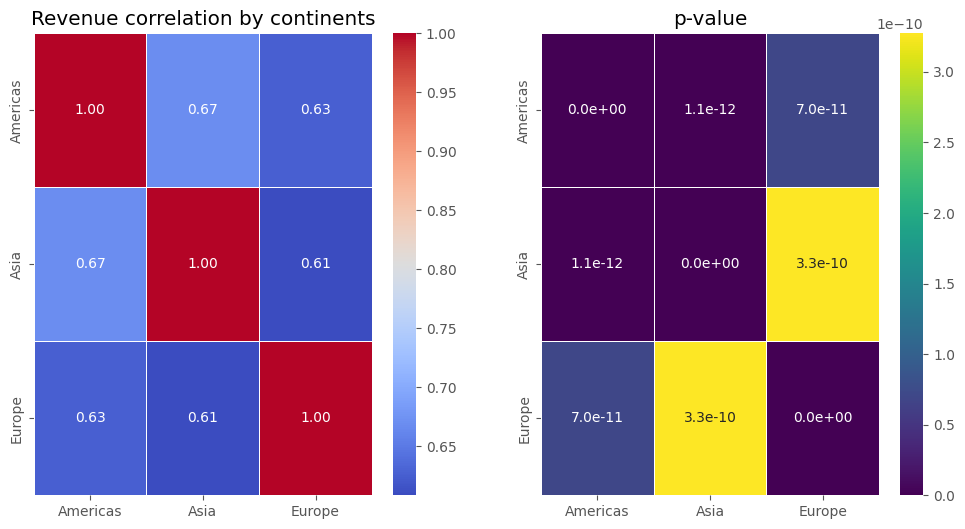

In [ ]:
region_pivot = df[df['continent'].isin(['Americas', 'Europe', 'Asia'])].pivot_table(index='order_date', columns='continent', values='revenue', aggfunc='sum').dropna()

corr_matrix, p_matrix = stats.spearmanr(region_pivot)

continent_names = region_pivot.columns

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax = axes[0], xticklabels=continent_names, yticklabels=continent_names)
axes[0].set_title('Revenue correlation by continents')

sns.heatmap(p_matrix, annot=True, cmap='viridis', fmt=".1e", linewidths=0.5, ax = axes[1], xticklabels=continent_names, yticklabels=continent_names, )
axes[1].set_title('p-value')

plt.show()

**Inter-Continental Revenue Correlation:**

A Spearman correlation analysis of regional performance reveals a moderate level of synchronization (ρ ≈ 0.61–0.67). This indicates that while the global business follows a general trend, each continent maintains significant operational autonomy. The lack of extreme correlation (>0.80) suggests a healthy level of geographic diversification, reducing the risk of a single-market collapse impacting the entire global revenue stream. Americas and Asia show the tightest alignment, while Europe remains the most independent (and volatile) market segment.

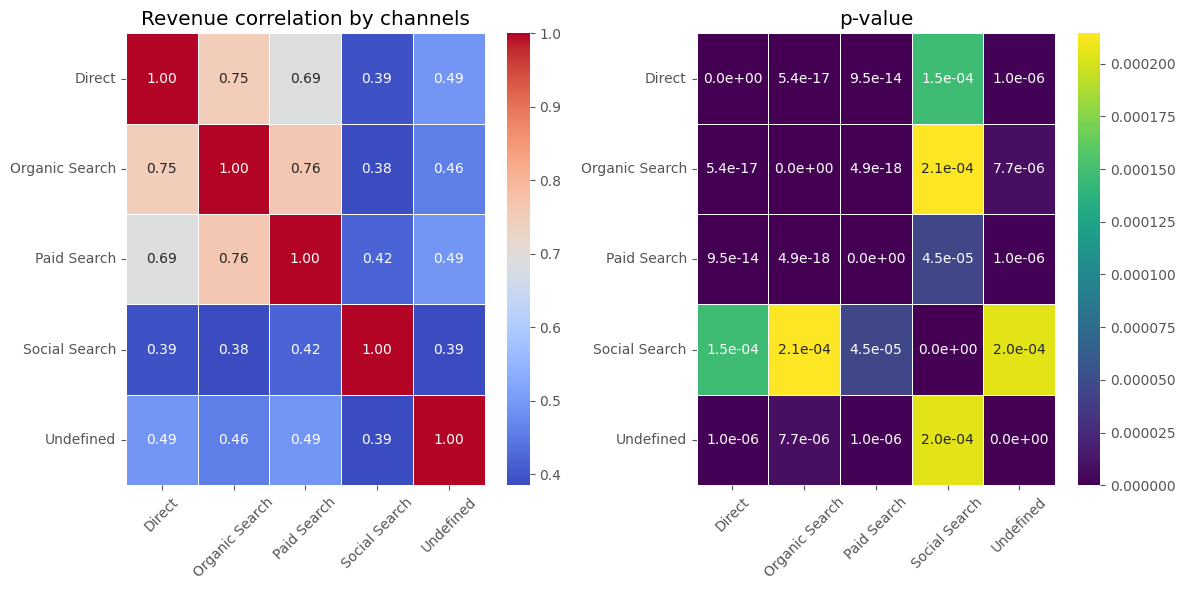

In [ ]:
channels_pivot = df.pivot_table(index='order_date', columns='traffic_channel', values='revenue', aggfunc='sum').dropna()

corr_matrix, p_matrix = stats.spearmanr(channels_pivot)

channels_names = channels_pivot.columns

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax = axes[0], xticklabels=channels_names, yticklabels=channels_names)
axes[0].set_title('Revenue correlation by channels')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(p_matrix, annot=True, cmap='viridis', fmt=".1e", linewidths=0.5, ax = axes[1], xticklabels=channels_names, yticklabels=channels_names)
axes[1].set_title('p-value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- **Core Ecosystem Stability & Synergy**

Analysis confirms a robust synergy between Direct, Organic, and Paid channels (p < 0.001). This indicates a highly mature marketing ecosystem where paid acquisition effectively stimulates organic demand and brand recall, creating a self-reinforcing growth loop.

- **Social Media Autonomy**

Social Search operates as an independent revenue driver, exhibiting a weak-to-moderate correlation (approx. 0.40) with other channels. This suggests that the social media audience follows a distinct behavioral pattern, remaining largely decoupled from the brand's broader marketing cycles and seasonal baseline.

- **Data Attribution Gaps & Integrity**

The moderate correlation between the 'Undefined' category and primary acquisition channels highlights a significant technical attribution gap.

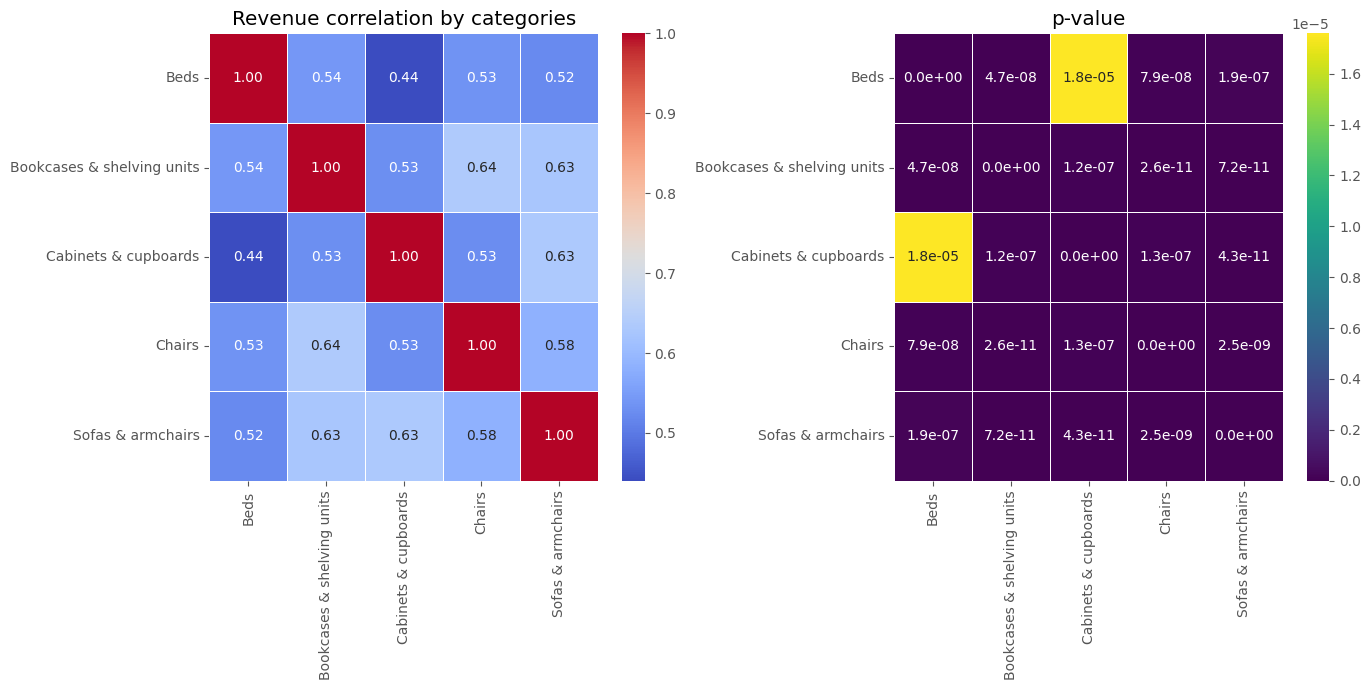

In [ ]:
top_5_categories = df.groupby('category')['revenue'].sum().sort_values(ascending = False).head(5).index

categories_pivot = df[df['category'].isin(top_5_categories)].pivot_table(index='order_date', columns='category', values='revenue', aggfunc='sum').dropna()

corr_matrix, p_matrix = stats.spearmanr(categories_pivot)

categories_names = categories_pivot.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax = axes[0], xticklabels=categories_names, yticklabels=categories_names)
axes[0].set_title('Revenue correlation by categories')


sns.heatmap(p_matrix, annot=True, cmap='viridis', fmt=".1e", linewidths=0.5, ax = axes[1], xticklabels=categories_names, yticklabels=categories_names)
axes[1].set_title('p-value')


plt.tight_layout()
plt.show()

- **Systemic Growth Driver**

The moderate positive correlation observed across all product categories confirms that revenue scaling is driven by platform-wide growth rather than isolated 'star products.' This trend reflects high customer lifetime value (CLV) and brand loyalty, as users demonstrate a strong propensity to consolidate their furniture purchases within a single ecosystem.

- **Contextual Bundling & Cross-Selling Potential**

The strongest correlations are identified between living room and home office categories (Bookcases, Chairs, and Sofas; r = 0.64). This indicates a significant opportunity for contextual bundling and enhanced personalized recommendation engines, as these products are frequently part of a single purchasing decision.

- **Specific Demand for Beds**

The 'Beds' category exhibits the highest degree of market autonomy, showing minimal dependence on fluctuations within adjacent categories. As a stable anchor for the business, it requires a dedicated, category-specific marketing strategy to capitalize on its unique demand cycle."

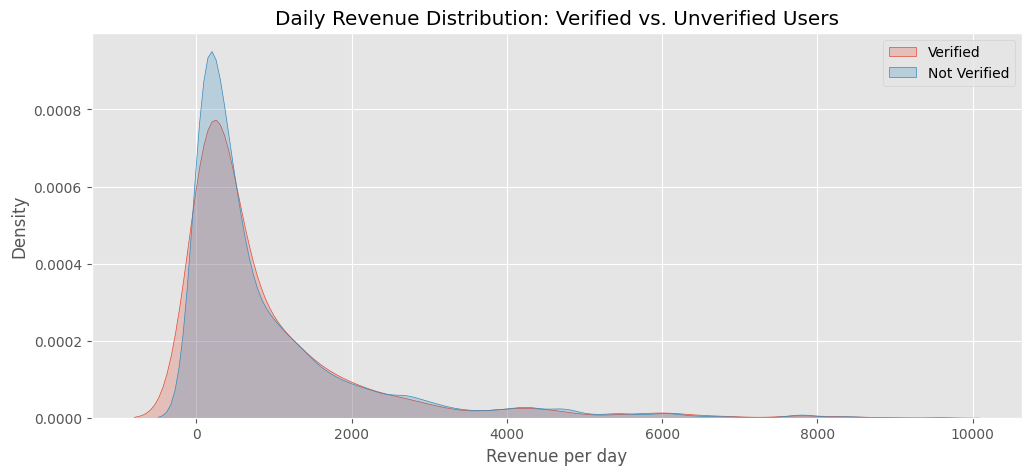

Shapiro-Wilk Verified: p=4.2142e-59
Shapiro-Wilk Not Verified: p=1.2908e-115


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30757.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
registered_df = df[~df['account_id'].isna()]['revenue']
not_registered_df = df[df['account_id'].isna()]['revenue']

plt.figure(figsize=(12, 5))
sns.kdeplot(registered_df, label='Registered', fill=True)
sns.kdeplot(not_registered_df, label='Not registered', fill=True)
plt.title('Daily Revenue Distribution: Registered vs. Not registered Users')
plt.xlabel('Revenue per day')
plt.legend()
plt.show()

print(f"Shapiro-Wilk Verified: p={stats.shapiro(registered_df)[1]:.4e}")
print(f"Shapiro-Wilk Not Verified: p={stats.shapiro(not_registered_df)[1]:.4e}")

The data distributions are non-normal, the Mann-Whitney U test will be applied to evaluate the statistical significance of the differences between the groups.

In [ ]:
u_stat, p_value = stats.mannwhitneyu(registered_df, not_registered_df, alternative='two-sided')

print(f"U stat: {u_stat}")
print(f"p-value: {p_value:.4e}")

U stat: 41771375.0
p-value: 4.1591e-02


In [ ]:
registered_accs_revenue = df[~df['account_id'].isna()]['revenue'].sum() / df['revenue'].sum() * 100
registered_acs_orders = len(df[~df['account_id'].isna()]['session_id']) / len(df['session_id']) * 100
number_of_registered = df['account_id'].nunique()
orders_of_registered = df[~df['account_id'].isna()]['session_id'].count()
print(f"Revenue Share (Registered Users): {registered_accs_revenue:,.2f}%;\nOrder Share (Registered Users): {registered_acs_orders:,.2f}%\nTotal Registered User Count: {number_of_registered}\nOrder Volume (Registered Users): {orders_of_registered}")

Revenue Share (Registered Users): 8.08%;
Order Share (Registered Users): 8.29%
Total Registered User Count: 2781
Order Volume (Registered Users): 2781


- **Key Finding: The Monetization Paradox**

The statistical analysis reveals a paradoxical outcome: despite the Mann-Whitney U test indicating statistical significance (p < 0.05), there is a complete absence of practical significance. Registered users account for 8.29% of transactions and generate a nearly identical 8.08% share of revenue. This suggests that, currently, account registration has zero impact on user monetization levels.

- **Retention and Short-term ROI**

Given the zero retention rate observed over the 88-day analysis period, modifying the registration system with the expectation of immediate revenue growth is unjustified.

- **Strategic Imperative: Data vs. Revenue**

However, expanding the registered user base remains a strategic necessity. Currently, 92% of revenue originates from the anonymous segment, resulting in "analytical blindness." This lack of identity data prevents the business from tracking Customer Lifetime Value (LTV) and implementing service personalization. Therefore, reforming the registration system should be viewed not as a financial lever, but as a critical data-acquisition tool required for future business process optimization.

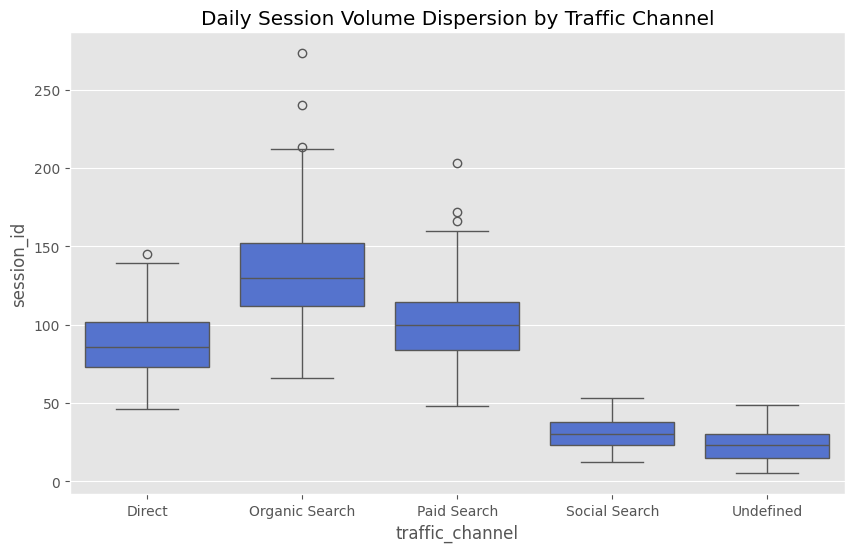

H-stat: 244.7949
p-value: 4.1591e-02


In [ ]:
daily_sessions = df.groupby(['order_date', 'traffic_channel'])['session_id'].count().reset_index()

organic = daily_sessions[daily_sessions['traffic_channel'] == 'Organic Search']['session_id']
direct = daily_sessions[daily_sessions['traffic_channel'] == 'Direct']['session_id']
paid = daily_sessions[daily_sessions['traffic_channel'] == 'Paid Search']['session_id']
social = daily_sessions[daily_sessions['traffic_channel'] == 'Social Search']['session_id']

plt.figure(figsize=(10, 6))
sns.boxplot(x='traffic_channel', y='session_id', data=daily_sessions, color = 'royalblue')
plt.title('Daily Session Volume Dispersion by Traffic Channel')
plt.show()

h_stat, p_val = stats.kruskal(organic, direct, paid, social)

print(f"H-stat: {h_stat:.4f}")
print(f"p-value: {p_value:.4e}")

- **Kruskal-Wallis Test Results:**

The test yielded a p-value of < 0.05, confirming statistically significant heterogeneity in session volumes across different traffic channels. This indicates that acquisition channels possess varying potential for attracting anonymous users. However, while the test identifies overall variance, a Post-hoc analysis is required to determine specific pairwise differences between high-performing and underperforming channels.

In [ ]:
import statsmodels.api as sm

df['is_organic'] = df['traffic_channel'] == 'Organic Search'

calc = df[df['continent'].isin(['Americas', 'Europe'])].groupby('continent').agg(organic_count=('is_organic', 'sum'), total_count=('session_id', 'count'))

calc.head()

counts = [calc.loc['Americas', 'organic_count'], calc.loc['Europe', 'organic_count']]
nobs = [calc.loc['Americas', 'total_count'], calc.loc['Europe', 'total_count']]

z_stat, p_value = sm.stats.proportions_ztest(counts, nobs)

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")

Z-statistic: -0.7388657778581375
P-value: 0.45998850476985065


- **Comparative Analysis of Traffic Structure:**

A Z-test for Proportions was conducted to compare traffic distribution across continents (Americas vs. Europe). The analysis yielded no statistically significant differences (p = 0.46). This indicates that user acquisition patterns are identical across both markets, suggesting that geographical location does not influence the choice of engagement channels.

#Summary:

The study involved a comprehensive analysis of the user base, traffic composition, and monetization patterns over an 88-day period. Key findings and critical insights are outlined below:

- Revenue Dynamics & Volatility Drivers

The analyzed period is characterized by a revenue plateau, with a strictly flat regression line indicating no systemic growth.

The "Outlier Hypothesis" Rejected: While the data shows extreme positive skewness (transactions up to 9,500),

Spearman’s Correlation (ρ): 0.9510

Statistical Significance (p-value): 1.35e-45

proves a near-perfect monotonic relationship between revenue and order volume.

Conclusion: High-ticket "whales" do not distort the trend. Revenue spikes are driven by traffic density and conversion volume (moving in lockstep), not by isolated expensive orders. Performance is currently dependent on stochastic daily traffic rather than scalable growth.

- Efficiency of the Verification and Loyalty System

Statistical analysis reveals a paradoxical situation: despite the mathematical significance of group differences (Mann-Whitney U test, p=0.0416), the practical significance of registration is effectively zero. Registered users contribute 8.08% of total revenue, which is nearly identical to their 8.29% share of total orders. This indicates that account status currently has no measurable impact on average order value.

A critical defect in Customer Retention was identified: the average order frequency for registered users is exactly 1.0. Given the sufficient observation window (88 days), this suggests that registration serves as a formal technical step rather than a functional loyalty driver.

- Traffic Acquisition Strategy Analysis

A Kruskal-Wallis test (p < 0.05) confirmed statistically significant heterogeneity across traffic sources. Organic Search remains the primary stable driver of the ecosystem, maintaining the highest median of daily sessions.

Conversely, a Z-test for Proportions revealed no significant differences in organic traffic structure between the Americas and Europe (p=0.46). This confirms that the current model—focused on anonymous traffic acquisition without subsequent retention—is systemic and independent of geographical markets.

- Strategic Risks and Recommendations

"Analytical Blindness":
Currently, 92% of revenue is generated by unidentified (anonymous) users. This prevents the calculation of Customer Lifetime Value (LTV), the execution of retargeting campaigns, and the development of predictive models, leaving the business vulnerable to fluctuations in Customer Acquisition Cost (CAC).

Strategic Recommendation:
The modernization of the registration system should not be viewed as a direct lever for immediate revenue growth. Instead, it is a strategic necessity for data acquisition. The business must imbue "registered status" with tangible value (e.g., loyalty programs, personalization) to transform the current anonymous streaming model into a predictable, data-driven customer base.

#[Link to dataset](https://drive.google.com/file/d/1oN22Dk25ghN9T1Osy8oTGuMuwwLNav_H/view)

#[Link to Tableau](https://public.tableau.com/shared/PTZM74BFW?:display_count=n&:origin=viz_share_link)